<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Logistic%20Regression%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     GENERATED HEART DISEASE DATASET

First 10 Rows:
   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  target
0   67    1   2       108   362    0      169      0     3.50       1
1   57    0   0       190   154    1      141      1     1.52       1
2   43    1   1       133   212    0      104      1     2.70       1
3   71    1   1       148   326    1       99      1     5.75       1
4   36    0   3       138   332    0      147      1     2.39       1
5   49    1   1       150   278    0      153      0     5.04       1
6   67    0   0       106   143    1      182      1     1.13       1
7   47    0   1       163   123    1       94      1     4.03       1
8   51    0   2       146   339    1      157      0     5.86       1
9   39    0   2       144   139    1       83      1     0.61       1

Dataset Shape:
(600, 10)

Target Distribution:
target
1    580
0     20
Name: count, dtype: int64

Training Data: (480, 9)
Testing Data: (120, 9)

     LOGISTIC REGRESSION RESU

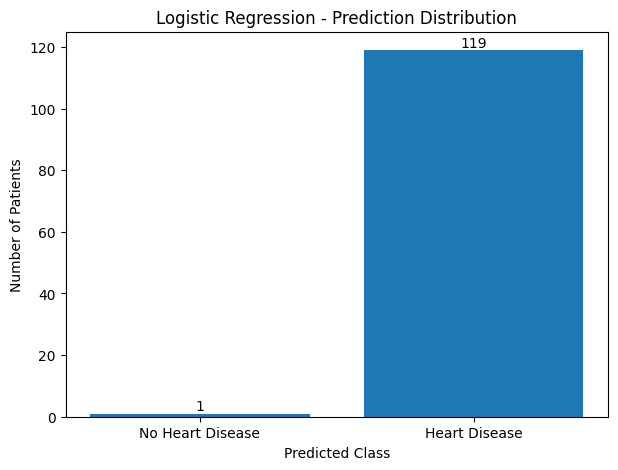

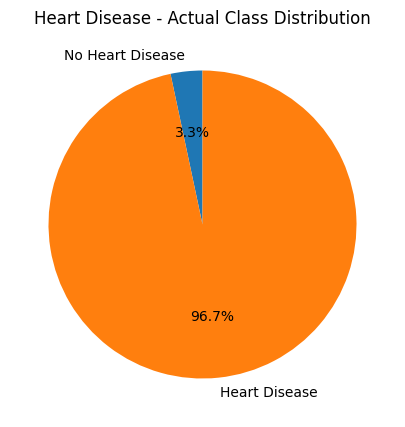

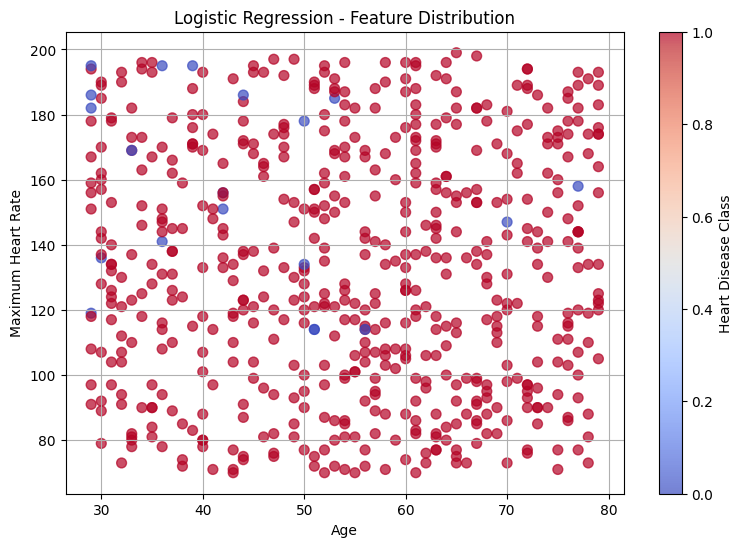


           FINAL RESULT
Logistic Regression Accuracy = 95.83%

Graphs Generated:
1. Prediction Distribution
2. Actual Class Distribution
3. Feature Distribution (Scatter Plot)


In [11]:
# ============================================================
# LOGISTIC REGRESSION - HEART DISEASE DATASET
# DATASET GENERATED INSIDE THE CODE
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 2. GENERATE HEART DISEASE DATASET
# ------------------------------------------------------------

np.random.seed(42)

n = 600

# Age
age = np.random.randint(
    29,
    80,
    n
)

# Sex
sex = np.random.randint(
    0,
    2,
    n
)

# Chest pain type
cp = np.random.randint(
    0,
    4,
    n
)

# Resting blood pressure
trestbps = np.random.randint(
    90,
    200,
    n
)

# Cholesterol
chol = np.random.randint(
    120,
    400,
    n
)

# Fasting blood sugar
fbs = np.random.randint(
    0,
    2,
    n
)

# Maximum heart rate
thalach = np.random.randint(
    70,
    200,
    n
)

# Exercise induced angina
exang = np.random.randint(
    0,
    2,
    n
)

# ST depression
oldpeak = np.round(
    np.random.uniform(
        0,
        6,
        n
    ),
    2
)


# ------------------------------------------------------------
# 3. CREATE HEART DISEASE TARGET
# ------------------------------------------------------------

# Create a disease risk score

risk_score = (
    -2.0
    + 0.035 * age
    + 0.35 * sex
    + 0.45 * cp
    + 0.008 * (trestbps - 120)
    + 0.003 * (chol - 200)
    + 0.50 * fbs
    - 0.015 * (thalach - 140)
    + 0.80 * exang
    + 0.35 * oldpeak
)


# Add random noise

risk_score += np.random.normal(
    0,
    0.8,
    n
)


# Convert risk score into binary class

heart_disease = (
    risk_score > 0
).astype(int)


# ------------------------------------------------------------
# 4. CREATE DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame({

    "age": age,

    "sex": sex,

    "cp": cp,

    "trestbps": trestbps,

    "chol": chol,

    "fbs": fbs,

    "thalach": thalach,

    "exang": exang,

    "oldpeak": oldpeak,

    "target": heart_disease

})


# ------------------------------------------------------------
# 5. DISPLAY DATASET
# ------------------------------------------------------------

print("======================================")
print("     GENERATED HEART DISEASE DATASET")
print("======================================")

print("\nFirst 10 Rows:")
print(df.head(10))

print("\nDataset Shape:")
print(df.shape)

print("\nTarget Distribution:")
print(df["target"].value_counts())


# ------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    "target",
    axis=1
)

y = df["target"]


# ------------------------------------------------------------
# 7. TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


print("\nTraining Data:", X_train.shape)

print(
    "Testing Data:",
    X_test.shape
)


# ------------------------------------------------------------
# 8. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ------------------------------------------------------------
# 9. CREATE LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


# ------------------------------------------------------------
# 10. TRAIN MODEL
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 11. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 12. CALCULATE ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


# ------------------------------------------------------------
# 13. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n======================================")
print("     LOGISTIC REGRESSION RESULTS")
print("======================================")

print(
    f"Accuracy = {accuracy:.4f}"
)

print(
    f"Accuracy Percentage = "
    f"{accuracy * 100:.2f}%"
)


# ------------------------------------------------------------
# 14. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,

        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)


# ============================================================
# GRAPH 1 - PREDICTION DISTRIBUTION
# ============================================================

prediction_counts = pd.Series(
    y_pred
).value_counts().reindex(
    [0, 1],
    fill_value=0
)


plt.figure(
    figsize=(7, 5)
)

plt.bar(
    [
        "No Heart Disease",
        "Heart Disease"
    ],

    prediction_counts.values
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Number of Patients"
)

plt.title(
    "Logistic Regression - Prediction Distribution"
)


# Display values

for i, value in enumerate(
    prediction_counts.values
):

    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )


plt.show()


# ============================================================
# GRAPH 2 - ACTUAL CLASS DISTRIBUTION
# ============================================================

actual_counts = pd.Series(
    y_test
).value_counts().reindex(
    [0, 1],
    fill_value=0
)


plt.figure(
    figsize=(7, 5)
)

plt.pie(

    actual_counts.values,

    labels=[
        "No Heart Disease",
        "Heart Disease"
    ],

    autopct="%1.1f%%",

    startangle=90

)

plt.title(
    "Heart Disease - Actual Class Distribution"
)

plt.show()


# ============================================================
# GRAPH 3 - FEATURE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


# Age vs Maximum Heart Rate

plt.scatter(

    df["age"],

    df["thalach"],

    c=df["target"],

    cmap="coolwarm",

    s=50,

    alpha=0.7

)


plt.xlabel(
    "Age"
)

plt.ylabel(
    "Maximum Heart Rate"
)

plt.title(
    "Logistic Regression - Feature Distribution"
)

plt.colorbar(
    label="Heart Disease Class"
)

plt.grid(True)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("           FINAL RESULT")
print("======================================")

print(
    f"Logistic Regression Accuracy = "
    f"{accuracy * 100:.2f}%"
)

print("\nGraphs Generated:")

print(
    "1. Prediction Distribution"
)

print(
    "2. Actual Class Distribution"
)

print(
    "3. Feature Distribution (Scatter Plot)"
)